# What makes a clip *Angry*? - source contrast analysis

The `Angry/` folder mixes **4 datasets** (RAVDESS, CREMA-D, TESS, SAVEE), which have very
different recording characteristics. This notebook separates the **source signal** from the
**emotion signal** to answer: *which features are shared across all sources to make a clip sound
Angry?*

**Method**
1. Build a feature table for **Angry** + a baseline (**Neutral**), tagged by `source` and `emotion`.
2. Show the **source differences** (PCA) - the domain shift.
3. **Per-source standardize** to remove that shift, keeping the emotion signal.
4. Measure **Angry vs Neutral** effect size **per source** - features that separate them the
   *same way in all 4 sources* are the robust, source-shared **angry signature.**

> **Setup:** `pip install librosa scikit-learn pandas numpy matplotlib seaborn scipy`

In [12]:
import re, numpy as np, pandas as pd
import librosa
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("librosa", librosa.__version__)

librosa 0.11.0


## 1. Configuration

In [13]:
TARGET   = "Angry"     # emotion we're characterizing (folder name)
CONTRAST = "Neutral"      # baseline to contrast against
EMO_DIR  = Path("../Emotions")
SR       = 22050
N_PER    = None           # None = ALL clips per source/emotion (slow; CREMA-D dominates)
PROSODIC = ["pitch", "rms", "zcr", "centroid", "bandwidth", "rolloff"]
STATS    = ["mean", "std", "low", "high", "range"]
feats    = ["duration"] + [f"{p}_{s}" for p in PROSODIC for s in STATS]

def source_of(name):
    if re.match(r"^03-", name):                   return "RAVDESS"
    if re.match(r"^\d{4}_", name):               return "CREMA-D"
    if re.match(r"^(OAF|YAF)_", name):            return "TESS"
    if re.match(r"^[a-z]{1,2}\d+\.wav$", name):   return "SAVEE"
    return "other"

## 2. Build the feature table (Angry + Neutral, across sources)

In [14]:
def _summ(name, arr, row):
    """mean, std, and robust low/high (5th/95th pct) + range for a per-frame feature."""
    row[f"{name}_mean"]  = float(np.nanmean(arr))
    row[f"{name}_std"]   = float(np.nanstd(arr))
    row[f"{name}_low"]   = float(np.nanpercentile(arr, 5))
    row[f"{name}_high"]  = float(np.nanpercentile(arr, 95))
    row[f"{name}_range"] = row[f"{name}_high"] - row[f"{name}_low"]

def feat_row(path):
    y, sr = librosa.load(path, sr=SR)
    f0   = librosa.yin(y, fmin=65, fmax=2093, sr=sr)
    rms  = librosa.feature.rms(y=y)[0]
    zcr  = librosa.feature.zero_crossing_rate(y)[0]
    cen  = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bw   = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rol  = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    d1   = librosa.feature.delta(mfcc); d2 = librosa.feature.delta(mfcc, order=2)

    row = {"duration": float(librosa.get_duration(y=y, sr=sr))}
    for name, arr in [("pitch", f0), ("rms", rms), ("zcr", zcr),
                      ("centroid", cen), ("bandwidth", bw), ("rolloff", rol)]:
        _summ(name, arr, row)
    for i in range(13):
        row[f"mfcc{i+1}"]   = float(mfcc[i].mean())
        row[f"delta{i+1}"]  = float(d1[i].mean())
        row[f"delta2{i+1}"] = float(d2[i].mean())
    return row

rows = []
for emo in [TARGET, CONTRAST]:
    by_src = {}
    for f in sorted((EMO_DIR / emo).glob("*.wav")):
        s = source_of(f.name)
        if s != "other":
            by_src.setdefault(s, []).append(f)
    for s, files in by_src.items():
        for f in files[:N_PER]:
            rows.append({"source": s, "emotion": emo, **feat_row(f)})

df = pd.DataFrame(rows)
print("Rows per source/emotion:")
print(df.groupby(["emotion", "source"]).size())
df.head()

Rows per source/emotion:
emotion  source 
Angry    CREMA-D    60
         RAVDESS    60
         SAVEE      60
         TESS       60
Neutral  CREMA-D    60
         RAVDESS    60
         SAVEE      60
         TESS       60
dtype: int64


,source,emotion,duration,rms,pitch,zcr,centroid,bandwidth,rolloff,mfcc1,...,delta210,mfcc11,delta11,delta211,mfcc12,delta12,delta212,mfcc13,delta13,delta213
0,RAVDESS,Angry,3.870567,0.008675,155.021250,0.333572,3314.368108,2543.174500,6119.040045,-546.115540,...,8.565937e-09,-0.857797,-5.710625e-09,0.000000,-4.766825,-1.427656e-09,-5.710625e-09,-0.710253,2.855312e-09,-5.710625e-09
1,RAVDESS,Angry,3.670340,0.006892,264.263172,0.248213,2520.841076,2046.588498,4716.990345,-562.574463,...,-2.377549e-03,-2.981067,5.750383e-03,-0.002818,-2.349607,4.496805e-03,-3.297766e-03,-4.839126,3.367048e-03,-3.790212e-03
2,RAVDESS,Angry,4.004036,0.002378,111.251225,0.236814,2994.199342,2679.908836,5896.923687,-612.098877,...,-3.566250e-02,-5.157606,1.136827e-02,-0.030505,-4.032478,-5.698549e-02,-1.816887e-02,-2.544785,-1.399431e-02,-1.018733e-02
3,RAVDESS,Angry,3.703719,0.007930,250.431743,0.259592,2779.925722,2179.302847,5153.703003,-554.893677,...,1.158759e-04,-4.298001,-3.788859e-04,-0.000036,-8.199027,-4.068613e-04,-1.683921e-04,-3.746344,-4.082560e-04,-2.790093e-04
4,RAVDESS,Angry,3.870567,0.010968,279.785912,0.239615,2856.634690,2577.148330,5669.937371,-530.751099,...,-2.570923e-04,1.482001,1.233638e-04,-0.000325,-3.012779,1.824830e-04,-3.977878e-04,-2.508663,2.461793e-04,-4.764902e-04


## 3. Source differences (the domain shift)

PCA on the **raw** features, colored by source. Expect the 4 sources to occupy different regions.

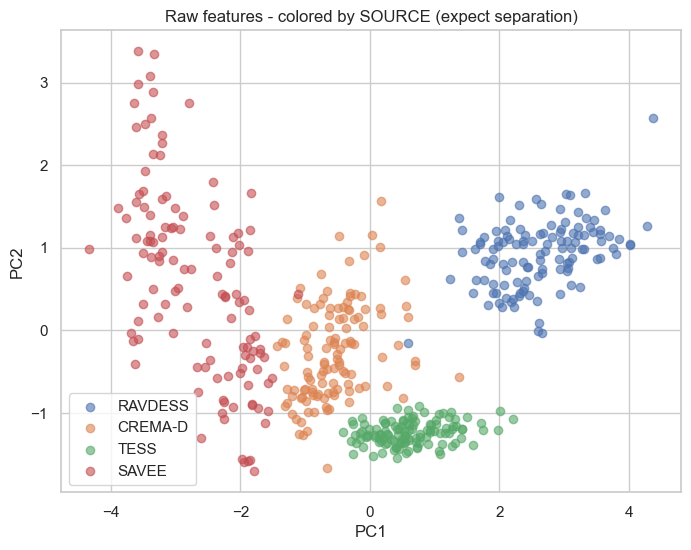

In [15]:
Xs = StandardScaler().fit_transform(df[feats])
pc = PCA(n_components=2).fit_transform(Xs)
plt.figure(figsize=(8, 6))
for s in df["source"].unique():
    m = df["source"].values == s
    plt.scatter(pc[m, 0], pc[m, 1], label=s, alpha=0.6)
plt.legend(); plt.title("Raw features - colored by SOURCE (expect separation)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

## 4. Remove the source shift - per-source standardization

Standardize each feature **within each source** (across both emotions): uniforms the sources while
keeping each clip's relative high/low, so what remains is the *emotion* signal.

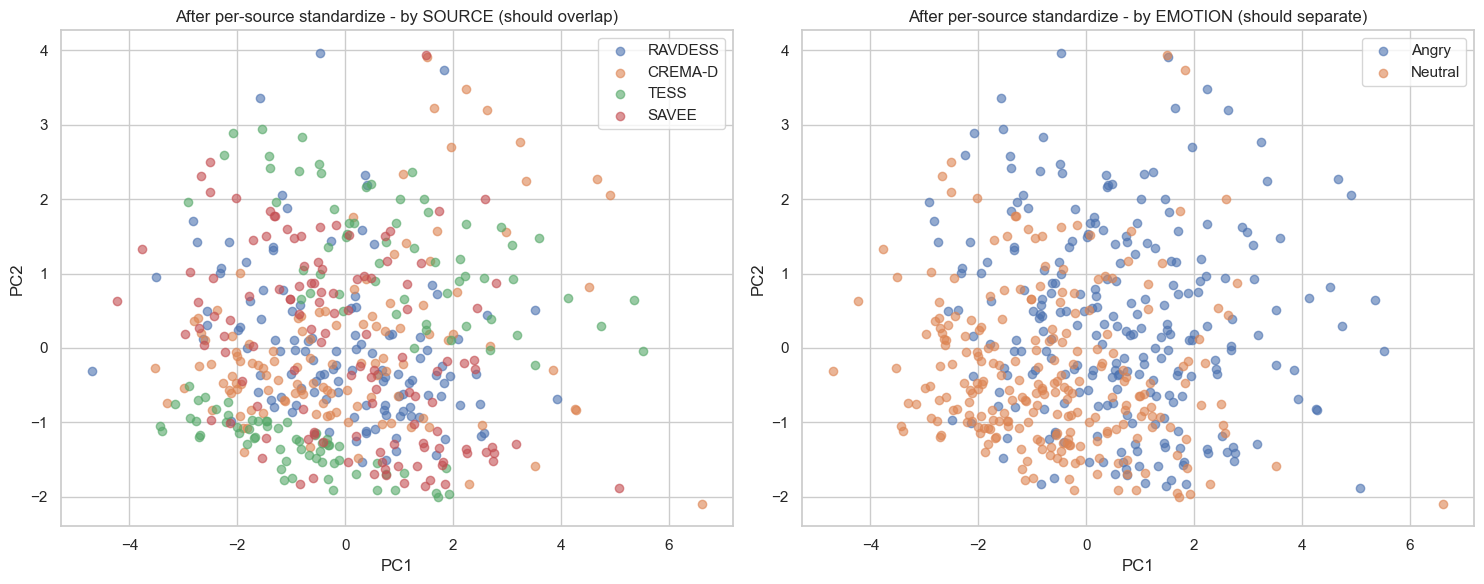

In [16]:
df_std = df.copy()
df_std[feats] = (df.groupby("source")[feats]
                   .transform(lambda g: (g - g.mean()) / (g.std() + 1e-9)))

pc2 = PCA(n_components=2).fit_transform(df_std[feats])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))
for s in df_std["source"].unique():
    m = df_std["source"].values == s
    a1.scatter(pc2[m, 0], pc2[m, 1], label=s, alpha=0.6)
a1.set_title("After per-source standardize - by SOURCE (should overlap)"); a1.legend()
for e in df_std["emotion"].unique():
    m = df_std["emotion"].values == e
    a2.scatter(pc2[m, 0], pc2[m, 1], label=e, alpha=0.6)
a2.set_title("After per-source standardize - by EMOTION (should separate)"); a2.legend()
for a in (a1, a2): a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 5. The shared angry signature - Angry vs Neutral, per source

Effect size (**Cohen's d**) of Angry vs Neutral for each feature, computed **separately per
source**. A feature is a robust, source-shared angry marker if its effect is **large** and the
**same sign in all 4 sources**.

In [17]:
def cohens_d(a, b):
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / (pooled + 1e-9)

eff = {}
for ft in feats:
    eff[ft] = {s: cohens_d(g[g.emotion==TARGET][ft], g[g.emotion==CONTRAST][ft])
               for s, g in df_std.groupby("source")}
eff = pd.DataFrame(eff).T
srcs = list(df_std["source"].unique())
eff["all_same_sign"] = eff[srcs].apply(lambda r: len(set(np.sign(r.round(2)))) == 1, axis=1)
eff["mean_effect"]   = eff[srcs].mean(axis=1)
eff = eff.sort_values("mean_effect", key=np.abs, ascending=False)
print(f"Cohen's d of {TARGET} vs {CONTRAST} (positive = higher in {TARGET}):")
display(eff.round(2))

Cohen's d of Angry vs Neutral (positive = higher in Angry):


,CREMA-D,RAVDESS,SAVEE,TESS,all_same_sign,mean_effect
pitch,0.99,0.27,-0.25,8.92,False,2.48
duration,-0.10,1.08,-0.51,-4.12,False,-0.91
centroid,1.11,0.20,0.88,1.12,True,0.83
rolloff,1.05,0.02,0.67,1.02,True,0.69
rms,1.90,1.41,-4.30,3.55,False,0.64
bandwidth,0.22,-0.16,2.36,0.07,False,0.62
zcr,1.05,-0.26,0.48,0.61,False,0.47


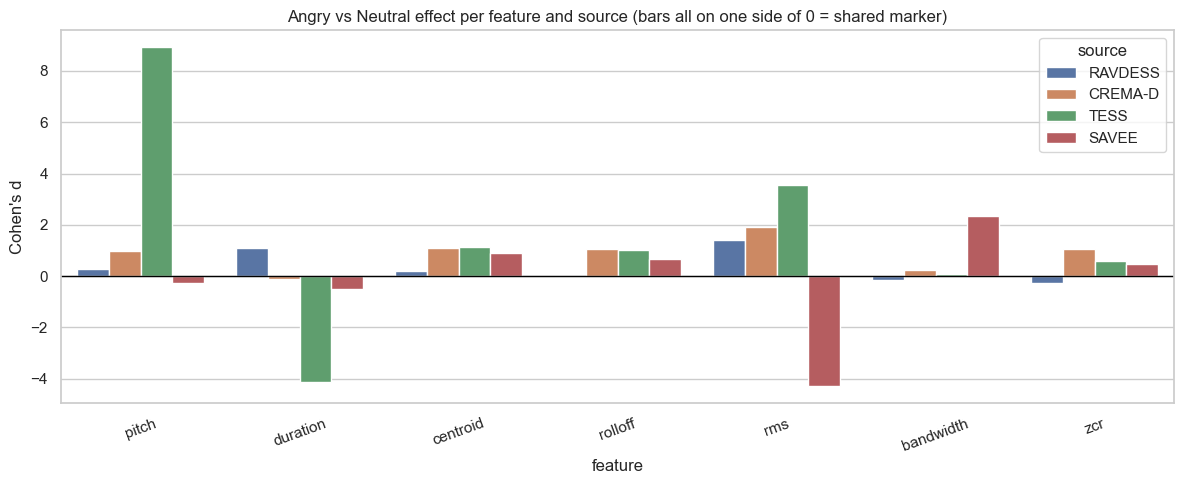

In [18]:
plot_df = eff[srcs].reset_index().melt(id_vars="index", var_name="source", value_name="cohens_d")
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="index", y="cohens_d", hue="source")
plt.axhline(0, color="black", lw=1)
plt.title(f"{TARGET} vs {CONTRAST} effect per feature and source "
          f"(bars all on one side of 0 = shared marker)")
plt.xlabel("feature"); plt.ylabel("Cohen's d"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

## 6. Interpretation

- Features with **`all_same_sign = True`** and a large **`mean_effect`** are the **source-shared
  markers of Angry** - present (same direction) across every dataset.
- Typical angry signature: **higher energy (rms), higher pitch, and brighter (centroid/rolloff) than neutral**. If these hold across all 4 sources, they're the reliable
  cues a model should lean on.
- Features whose sign **flips between sources** are *not* trustworthy angry cues - they're source
  artifacts, and leaning on them is what hurts cross-dataset generalization.

Change `TARGET` / `CONTRAST` in the config to redefine the comparison.

## 7. CNN classifier — Angry vs Neutral (85/15 split)

A small 1-D CNN that learns to separate **Angry from Neutral** using the **per-source standardized** prosodic **+ MFCC** features — so it relies on the source-invariant emotion signal, not recording
artifacts. Binary target, stratified 85/15 train/test split.

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# CNN features = prosodic + MFCC, per-source standardized (domain shift removed)
mfcc_cols = [c for c in df.columns if c.startswith(("mfcc", "delta"))]
cnn_feats = feats + mfcc_cols
Xdf = (df.groupby("source")[cnn_feats]
         .transform(lambda g: (g - g.mean()) / (g.std() + 1e-9))).fillna(0.0)
X = Xdf.astype("float32").values
y = (df["emotion"] == TARGET).astype(int).values
print(f"{len(cnn_feats)} features ({len(feats)} prosodic + {len(mfcc_cols)} MFCC+delta+delta2)")
print("Class balance:", {CONTRAST: int((y==0).sum()), TARGET: int((y==1).sum())})

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_tr = X_tr[..., np.newaxis]; X_te = X_te[..., np.newaxis]    # (n, n_features, 1) for Conv1D
print("Train:", X_tr.shape, " Test:", X_te.shape)

46 features (7 prosodic + 39 MFCC+delta+delta2)
Class balance: {'Neutral': 240, 'Angry': 240}
Train: (408, 46, 1)  Test: (72, 46, 1)


In [20]:
tf.random.set_seed(42)
model = keras.Sequential([
    keras.layers.Input(shape=X_tr.shape[1:]),
    layers.Conv1D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Conv1D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-3)),
    layers.Dropout(0.5),
    layers.Dense(2, activation="softmax"),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 46, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 46, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 46, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,866 (34.63 KB)

 Trainable params: 8,674 (33.88 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/80
22/22 - 1s - 61ms/step - accuracy: 0.5173 - loss: 0.7316 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 2/80
22/22 - 0s - 3ms/step - accuracy: 0.5954 - loss: 0.6680 - val_accuracy: 0.5484 - val_loss: 0.6896
Epoch 3/80
22/22 - 0s - 2ms/step - accuracy: 0.6763 - loss: 0.6286 - val_accuracy: 0.5323 - val_loss: 0.6852
Epoch 4/80
22/22 - 0s - 3ms/step - accuracy: 0.6792 - loss: 0.6217 - val_accuracy: 0.5484 - val_loss: 0.6806
Epoch 5/80
22/22 - 0s - 3ms/step - accuracy: 0.6705 - loss: 0.6143 - val_accuracy: 0.6290 - val_loss: 0.6763
Epoch 6/80
22/22 - 0s - 3ms/step - accuracy: 0.6908 - loss: 0.6028 - val_accuracy: 0.6935 - val_loss: 0.6727
Epoch 7/80
22/22 - 0s - 2ms/step - accuracy: 0.6618 - loss: 0.5986 - val_accuracy: 0.7097 - val_loss: 0.6638
Epoch 8/80
22/22 - 0s - 2ms/step - accuracy: 0.7197 - loss: 0.5731 - val_accuracy: 0.7258 - val_loss: 0.6574
Epoch 9/80
22/22 - 0s - 3ms/step - accuracy: 0.7139 - loss: 0.5766 - val_accuracy: 0.7258 - val_loss: 0.6527
Epoch 10/80
22/22 

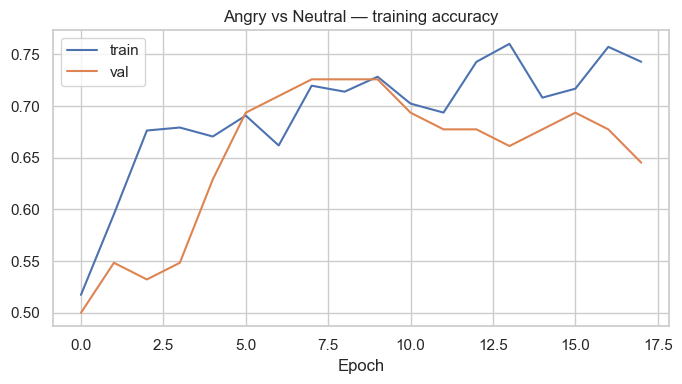

In [ ]:
cb = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=12,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=4, min_lr=1e-5),
]
history = model.fit(X_tr, y_tr, validation_split=0.15,
                    epochs=120, batch_size=32, callbacks=cb, verbose=2)

h = history.history
plt.figure(figsize=(7, 4))

plt.plot(h["accuracy"], label="train"); plt.plot(h["val_accuracy"], label="val")
plt.title(f"{TARGET} vs {CONTRAST} — training accuracy"); plt.xlabel("Epoch")
plt.legend(); plt.tight_layout(); plt.show()

Test accuracy: 0.694

              precision    recall  f1-score   support

     Neutral      0.667     0.778     0.718        36
       Angry      0.733     0.611     0.667        36

    accuracy                          0.694        72
   macro avg      0.700     0.694     0.692        72
weighted avg      0.700     0.694     0.692        72



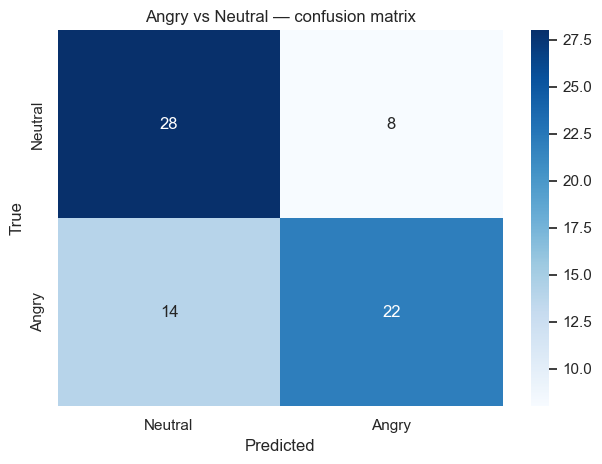

In [22]:
test_acc = model.evaluate(X_te, y_te, verbose=0)[1]
print(f"Test accuracy: {test_acc:.3f}\n")

y_pred = model.predict(X_te, verbose=0).argmax(axis=1)
print(classification_report(y_te, y_pred, target_names=[CONTRAST, TARGET], digits=3))

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CONTRAST, TARGET], yticklabels=[CONTRAST, TARGET])
plt.title(f"{TARGET} vs {CONTRAST} — confusion matrix")
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()